In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("cs-training.csv")
df.head(5)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [4]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.head(5)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Cleaning

In [7]:
#replcaing null values with median
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

print("Null values after imputation:", df.isnull().sum())

Null values after imputation: Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [8]:
df = df.drop('Unnamed: 0', axis=1)
print(df.columns)

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         150000 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    150000 non-null  float64
dtype

# Preprocessing and Feature Engineering

In [10]:
# Creating a new feature for total late payments
df['total_late_payments'] = (
    df['NumberOfTimes90DaysLate'] +
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse']
)

In [11]:
# Creating a new feature for debt-to-income ratio
df['debt_income_ratio'] = df['DebtRatio'] / (df['MonthlyIncome'] + 1)

In [12]:
df['credit_pressure'] = (
    df['RevolvingUtilizationOfUnsecuredLines'] * df['DebtRatio']
)

In [13]:
print(df.columns)

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'total_late_payments', 'debt_income_ratio',
       'credit_pressure'],
      dtype='object')


# Modeling

In [14]:
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
# Basic Logistic Regression pipeline
lr_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, class_weight="balanced")
)

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

print('Logistic Regression Accuracy:', accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=10, scoring='accuracy')
lr_f1_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=10, scoring='f1')
lr_recall_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=10, scoring='recall')
lr_roc_auc_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=10, scoring='roc_auc')
print('Logistic Regression CV mean:', lr_cv_scores.mean())
print('Logistic Regression F1 mean:', lr_f1_scores.mean())
print('Logistic Regression Recall mean:', lr_recall_scores.mean())
print('Logistic Regression ROC AUC mean:', lr_roc_auc_scores.mean())


Logistic Regression Accuracy: 0.7758666666666667
              precision    recall  f1-score   support

           0       0.97      0.78      0.87     27995
           1       0.18      0.67      0.29      2005

    accuracy                           0.78     30000
   macro avg       0.58      0.73      0.58     30000
weighted avg       0.92      0.78      0.83     30000

Logistic Regression CV mean: 0.7707583333333333
Logistic Regression F1 mean: 0.27420011900013486
Logistic Regression Recall mean: 0.6476734688807249
Logistic Regression ROC AUC mean: 0.7893526841444081


In [ ]:
# Basic KNN pipeline
knn_pipeline = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

knn_pipeline.fit(X_train, y_train)
knn_preds = knn_pipeline.predict(X_test)

print('KNN Accuracy:', accuracy_score(y_test, knn_preds))
print(classification_report(y_test, knn_preds))

knn_cv_scores = cross_val_score(knn_pipeline, X_train, y_train, cv=10, scoring='accuracy')
knn_f1_scores = cross_val_score(knn_pipeline, X_train, y_train, cv=10, scoring='f1')
knn_recall_scores = cross_val_score(knn_pipeline, X_train, y_train, cv=10, scoring='recall')
knn_roc_auc_scores = cross_val_score(knn_pipeline, X_train, y_train, cv=10, scoring='roc_auc')


print('KNN CV mean:', knn_cv_scores.mean())
print('KNN F1 mean:', knn_f1_scores.mean())
print('KNN Recall mean:', knn_recall_scores.mean())
print('KNN ROC AUC mean:', knn_roc_auc_scores.mean())

KNN Accuracy: 0.9330666666666667
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.50      0.14      0.22      2005

    accuracy                           0.93     30000
   macro avg       0.72      0.57      0.59     30000
weighted avg       0.91      0.93      0.92     30000

KNN CV mean: 0.9322000000000001
KNN F1 mean: 0.21191061049787052
KNN Recall mean: 0.13639251808212965
KNN ROC AUC mean: 0.6916363027205616


In [37]:
# Random Forest Classifier
rf_model = RandomForestClassifier(
    random_state=42, 
    class_weight="balanced_subsample" 
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=10, scoring='accuracy')
rf_f1_scores = cross_val_score(rf_model, X_train, y_train, cv=10, scoring='f1')
rf_recall_scores = cross_val_score(rf_model, X_train, y_train, cv=10, scoring='recall')
rf_roc_auc_scores = cross_val_score(rf_model, X_train, y_train, cv=10, scoring='roc_auc')


print('Random Forest CV mean:', rf_cv_scores.mean())
print('Random Forest F1 mean:', rf_f1_scores.mean())
print('Random Forest Recall mean:', rf_recall_scores.mean())
print('Random Forest ROC AUC mean:', rf_roc_auc_scores.mean())

Random Forest CV mean: 0.9346333333333334
Random Forest F1 mean: 0.24183571736657808
Random Forest Recall mean: 0.15609186870929775
Random Forest ROC AUC mean: 0.834953676628509


In [38]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.57      0.16      0.25      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.57      0.61     30000
weighted avg       0.92      0.94      0.92     30000



In [39]:
# XGBoost Classifier
# Calculate the ratio for scale_pos_weight (Negative Class Count / Positive Class Count)
# Assuming 0 is the majority (no default) and 1 is the minority (default)
class_0_count = (y_train == 0).sum()
class_1_count = (y_train == 1).sum()
scale_weight = class_0_count / class_1_count

xgb_model = XGBClassifier(
    random_state=42, 
    scale_pos_weight=scale_weight,
    eval_metric='auc' 
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print(classification_report(y_test, xgb_preds))

xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=10, scoring='accuracy')
xgb_f1_scores = cross_val_score(xgb_model, X_train, y_train, cv=10, scoring='f1')
xgb_recall_scores = cross_val_score(xgb_model, X_train, y_train, cv=10, scoring='recall')
xgb_roc_auc_scores = cross_val_score(xgb_model, X_train, y_train, cv=10, scoring='roc_auc')
print('XGBoost CV mean:', xgb_cv_scores.mean())
print('XGBoost F1 mean:', xgb_f1_scores.mean())
print('XGBoost Recall mean:', xgb_recall_scores.mean())
print('XGBoost ROC AUC mean:', xgb_roc_auc_scores.mean())


              precision    recall  f1-score   support

           0       0.98      0.83      0.90     27995
           1       0.23      0.70      0.35      2005

    accuracy                           0.82     30000
   macro avg       0.60      0.77      0.62     30000
weighted avg       0.93      0.82      0.86     30000

XGBoost CV mean: 0.8292083333333334
XGBoost F1 mean: 0.35302335200508433
XGBoost Recall mean: 0.6970435058058466
XGBoost ROC AUC mean: 0.8473812386654022


# Hyper Paramter Tuning

In [40]:
# Random Forest in-depth
from sklearn.model_selection import RandomizedSearchCV

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced_subsample')


param_dist = {
    'n_estimators': [100, 200, 300, 500],      
    'max_depth': [10, 15, 20, 30, None],       
    'min_samples_split': [2, 5, 10],           
    'min_samples_leaf': [1, 2, 4, 8],          
    'max_features': ['sqrt', 'log2', None]     
}

#Setting up the Randomized Search
rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,                 
    cv=5,                     
    scoring='roc_auc',         
    verbose=2,                 
    random_state=42,
    n_jobs=-1                  
)

print("Starting hyperparameter tuning...")
rf_random.fit(X_train, y_train)

#Printing the absolute best setup found
print("\n--- Tuning Complete ---")
print("Best Parameters:", rf_random.best_params_)
print("Best ROC AUC Score:", rf_random.best_score_)


#Saving the winning model to a new variable
best_rf_model = rf_random.best_estimator_

Starting hyperparameter tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Yehya\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



--- Tuning Complete ---
Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 10}
Best ROC AUC Score: 0.8609147958600006


In [41]:
print(classification_report(y_test, best_rf_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.83      0.90     27995
           1       0.24      0.74      0.36      2005

    accuracy                           0.82     30000
   macro avg       0.61      0.79      0.63     30000
weighted avg       0.93      0.82      0.86     30000



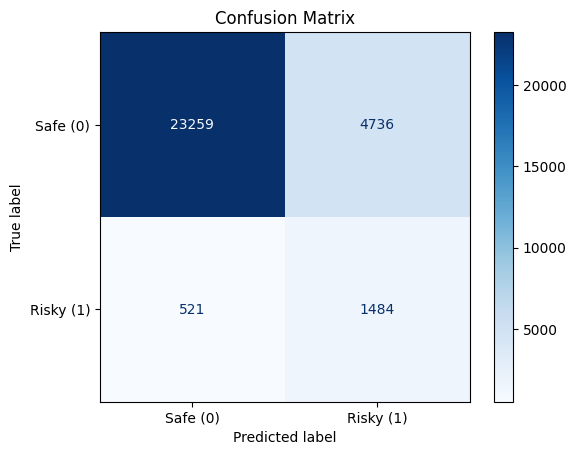

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, best_rf_model.predict(X_test))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe (0)", "Risky (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

           0       0.99      0.65      0.78     27995
           1       0.15      0.89      0.26      2005

    accuracy                           0.66     30000
   macro avg       0.57      0.77      0.52     30000
weighted avg       0.93      0.66      0.75     30000



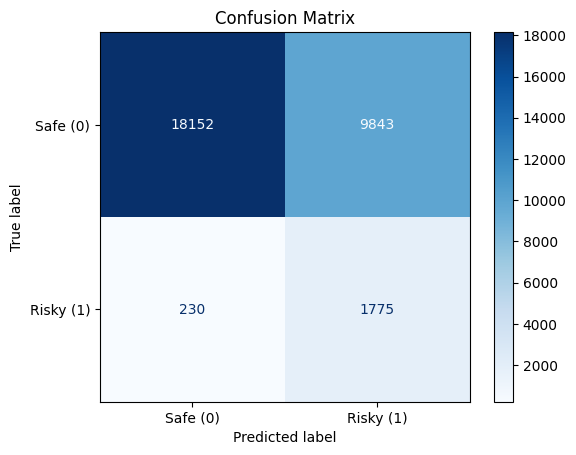

In [44]:
# getting raw probability scores
rf_probs = best_rf_model.predict_proba(X_test)[:, 1]

# Custom threshold
custom_threshold = 0.30 

# Applying the new rule: If probability is >= 0.30, label as 1, else 0
custom_preds = (rf_probs >= custom_threshold).astype(int)

print(classification_report(y_test, custom_preds))

cm_custom = confusion_matrix(y_test, custom_preds)
disp_custom = ConfusionMatrixDisplay(
    confusion_matrix=cm_custom,
    display_labels=["Safe (0)", "Risky (1)"]
)

disp_custom.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# The model did succeed in predicting out more defaulters but at the cost of flagging alot of safe customer as risky more than 2x the amount of the "best random forest model" without the threshold.. 

In [45]:
# Fine tuning XGBoost

# Recalculating scale_pos_weight for the training set (in case we did any resampling or changes)
class_0_count = (y_train == 0).sum()
class_1_count = (y_train == 1).sum()
scale_weight = class_0_count / class_1_count


xgb_base = XGBClassifier(
    random_state=42, 
    scale_pos_weight=scale_weight,
    eval_metric='auc' 
)

# XGBoost tuning grid
param_dist_xgb = {
    'n_estimators': [100, 200, 300],          
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  
    'max_depth': [3, 4, 5, 7],                
    'subsample': [0.7, 0.8, 1.0],             
    'colsample_bytree': [0.7, 0.8, 1.0]       
}

# Randomized Search
xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=15,                 
    cv=3,                      
    scoring='roc_auc',         
    verbose=2,
    random_state=42,
    n_jobs=-1                  
)


print("Starting XGBoost hyperparameter tuning...")
xgb_random.fit(X_train, y_train)


print("\n--- XGBoost Tuning Complete ---")
print("Best Parameters:", xgb_random.best_params_)
print("Best ROC AUC Score:", xgb_random.best_score_)

best_xgb_model = xgb_random.best_estimator_

Starting XGBoost hyperparameter tuning...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

--- XGBoost Tuning Complete ---
Best Parameters: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best ROC AUC Score: 0.8643894249772917


              precision    recall  f1-score   support

           0       0.98      0.79      0.88     27995
           1       0.21      0.79      0.34      2005

    accuracy                           0.79     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.79      0.84     30000



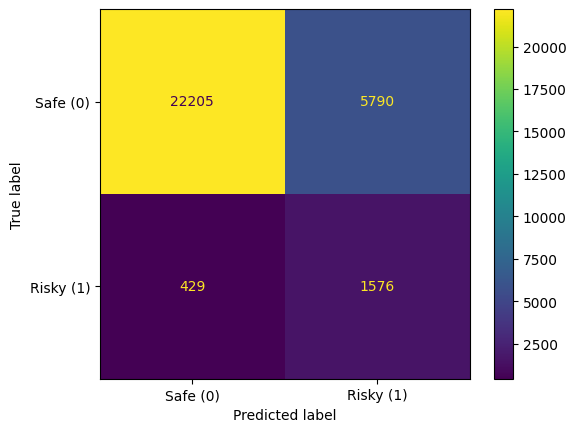

In [46]:
print(classification_report(y_test, best_xgb_model.predict(X_test)))
xgb_cm = confusion_matrix(y_test, best_xgb_model.predict(X_test))
xgb_disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["Safe (0)", "Risky (1)"]
)
xgb_disp.plot()

In [50]:
# Best Performing Models are Random Forest and XGBoost

print("Random Forest ROC AUC Score:", rf_random.best_score_)
print(classification_report(y_test, best_rf_model.predict(X_test)))
print("---------------------------------")
print("XGBoost ROC AUC Score:", xgb_random.best_score_)
print(classification_report(y_test, best_xgb_model.predict(X_test)))


Random Forest ROC AUC Score: 0.8609147958600006
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     27995
           1       0.24      0.74      0.36      2005

    accuracy                           0.82     30000
   macro avg       0.61      0.79      0.63     30000
weighted avg       0.93      0.82      0.86     30000

---------------------------------
XGBoost ROC AUC Score: 0.8643894249772917
              precision    recall  f1-score   support

           0       0.98      0.79      0.88     27995
           1       0.21      0.79      0.34      2005

    accuracy                           0.79     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.79      0.84     30000



# XGBOOST is the better choice business wise.